# Watch a model learn — live

**The whole demo in one sentence:** we ask the model a question it *cannot* know
the answer to → it fails → we let it **read** (no training run, no labels, just
inference) → we ask again → **it knows** → we hit reset → it forgets.

Validated end-to-end on an L40S. Expected outputs are inlined so you know what
you should see.

**The scenario.** Your company has three internal services with made-up owner
teams no model on earth was trained on:

| service | secret owner-team |
|---|---|
| payments | quokka |
| search | harpy |
| storage | ibex |

The model will encounter these facts only by *reading incident reports* while it runs.

In [1]:
# Cell 0 — load the model
# !pip install strands-slm matplotlib
import os, torch, random
import matplotlib.pyplot as plt
# os.environ["HF_TOKEN"] = "hf_..."   # while the model repo is private

from slm import StrandsPlasticQwen

# demo config: aggressive plasticity so learning is visible in minutes
# (production config lr=8e-3, decay=0.98 learns slower but keeps retention Δ≈0)
m = StrandsPlasticQwen.from_pretrained(
    device="cuda" if torch.cuda.is_available() else "cpu",
    r_fast=128, lr=5e-2, decay=0.999, k_gate=-10.0)
print("model loaded — plastic (changeable) params:",
      sum(p.numel() for p in [m.head.A, m.head.B]),
      f"({100*sum(p.numel() for p in [m.head.A, m.head.B])/sum(p.numel() for p in m.model.parameters()):.2f}% of the frozen 2.1B)")

/home/ubuntu/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


model loaded — plastic (changeable) params: 19709952 (0.92% of the frozen 2.1B)


## Step 1 — Ask BEFORE it has read anything

The question: *"the payments service degraded... paging owner-team ___"*

It has never seen these facts. Watch it flail.

In [2]:
# Cell 1 — the model does NOT know
OWNERS = {"payments": "quokka", "search": "harpy", "storage": "ibex"}
SVCS, TEAMS = list(OWNERS), list(OWNERS.values())

def question(svc):
    return f"incident 424242: the {svc} service degraded on host h55. paging owner-team"

def ask(model, svc, n_tokens=3):
    ids = model.tok(question(svc), return_tensors="pt").input_ids.to(model.device)
    with torch.no_grad():
        out = model.model.generate(input_ids=ids, max_new_tokens=n_tokens,
                                   do_sample=False, pad_token_id=model.tok.eos_token_id)
    return model.tok.decode(out[0, ids.shape[1]:], skip_special_tokens=True).strip()

def team_probs(model, svc):
    """P(team | question), restricted to the 3 candidate teams."""
    ids = model.tok(question(svc), return_tensors="pt").input_ids.to(model.device)
    with torch.no_grad():
        lg = model.model(input_ids=ids).logits[0, -1].float()
    tids = [model.tok(" "+t, add_special_tokens=False).input_ids[0] for t in TEAMS]
    return torch.softmax(torch.tensor([lg[t] for t in tids]), -1)

m.reset()
M_before = torch.stack([team_probs(m, s) for s in SVCS])
print("Q: ... paging owner-team ___\n")
for s in SVCS:
    print(f"  {s:<9}→ model says: {ask(m, s)!r:<18} (truth: {OWNERS[s]})")
# validated: all three answer ' for a fix' — it has no idea

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Q: ... paging owner-team ___



  payments → model says: 'for a fix'        (truth: quokka)
  search   → model says: 'for a fix'        (truth: harpy)


  storage  → model says: 'for a fix'        (truth: ibex)


## Step 2 — Let it READ

60 incident reports stream past — exactly like production logs. Each fact appears
once per report; the model must *accumulate* them across reports, in its weights.

For every report the model:
1. **predicts** it (surprise = how wrong it was)
2. **updates** its tiny fast-weight layer to be less wrong next time

We record three signals to visualize the learning as it happens.

In [3]:
# Cell 2 — the reading loop (this IS inference — no optimizer setup, no labels)
def make_report(rng):
    svc = rng.choice(SVCS)
    return (f"incident {rng.randint(10**5,10**6)}: the {svc} service degraded "
            f"on host h{rng.randint(10,99)}. paging owner-team {OWNERS[svc]}. "
            f"severity {rng.choice(['low','med','high'])}.")

rng = random.Random(0)
stream = [make_report(rng) for _ in range(60)]
print("example report:", stream[0], "\n")

EPOCHS = 15
surprise_log, weight_norm_log, p_correct_log = [], [], []

m.reset()
for epoch in range(EPOCHS):
    for doc in stream:
        s = m.observe(doc, learn=True)          # predict -> update fast weights
        surprise_log.append(s)
        weight_norm_log.append(float(m.head.B.norm()))
    p_correct_log.append(float(torch.stack(
        [team_probs(m, s) for s in SVCS]).diag().mean()))
    print(f"epoch {epoch+1:>2}: surprise {s:.3f}   "
          f"P(correct team) {p_correct_log[-1]:.3f}   ‖fast weights‖ {weight_norm_log[-1]:.1f}")

example report: incident 894772: the search service degraded on host h63. paging owner-team harpy. severity low. 



epoch  1: surprise 2.370   P(correct team) 0.251   ‖fast weights‖ 0.6


epoch  2: surprise 1.641   P(correct team) 0.256   ‖fast weights‖ 0.9


epoch  3: surprise 1.328   P(correct team) 0.282   ‖fast weights‖ 1.1


epoch  4: surprise 1.209   P(correct team) 0.326   ‖fast weights‖ 1.2


...

epoch 11: surprise 1.000   P(correct team) 0.632   ‖fast weights‖ 1.5


epoch 12: surprise 0.997   P(correct team) 0.663   ‖fast weights‖ 1.5


epoch 13: surprise 1.007   P(correct team) 0.702   ‖fast weights‖ 1.5


epoch 14: surprise 1.042   P(correct team) 0.711   ‖fast weights‖ 1.6


epoch 15: surprise 1.066   P(correct team) 0.735   ‖fast weights‖ 1.6


## Step 3 — Watch the learning (three views of one process)

- **surprise falls** — the model gets less wrong at predicting reports
- **fast weights grow** — physical change in the weight matrix, live
- **P(correct team) rises** — the *knowledge* becoming retrievable

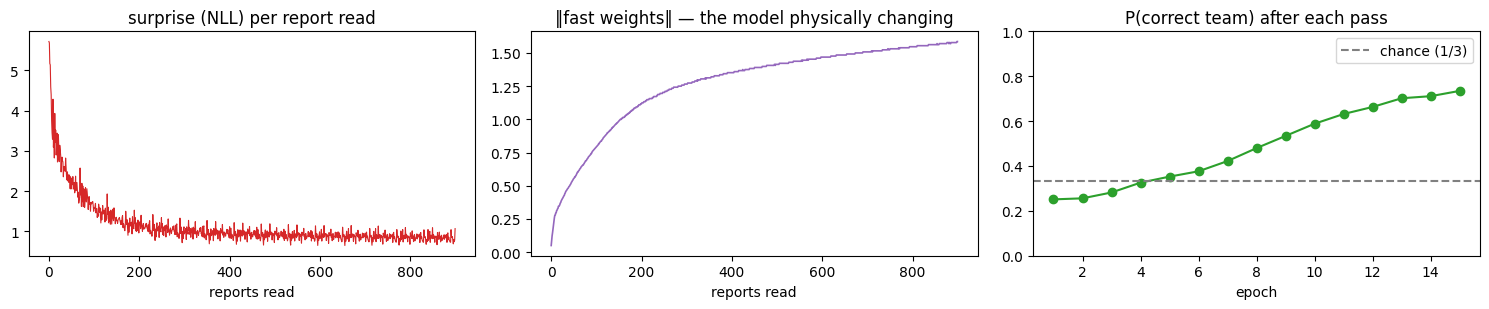

In [4]:
# Cell 3 — visualize
fig, ax = plt.subplots(1, 3, figsize=(15, 3.2))

ax[0].plot(surprise_log, lw=0.8, color="tab:red")
ax[0].set_title("surprise (NLL) per report read"); ax[0].set_xlabel("reports read")

ax[1].plot(weight_norm_log, lw=1.2, color="tab:purple")
ax[1].set_title("‖fast weights‖ — the model physically changing"); ax[1].set_xlabel("reports read")

ax[2].plot(range(1, EPOCHS+1), p_correct_log, marker="o", color="tab:green")
ax[2].axhline(1/3, ls="--", c="gray", label="chance (1/3)")
ax[2].set_title("P(correct team) after each pass"); ax[2].set_xlabel("epoch")
ax[2].set_ylim(0, 1); ax[2].legend()

plt.tight_layout(); plt.show()

## Step 4 — Ask AFTER. Now it knows.

Same questions, greedy decoding, nothing in the prompt to copy from —
the answers can only come from the weights it just rewrote.

In [5]:
# Cell 4 — the payoff
M_after = torch.stack([team_probs(m, s) for s in SVCS])
print("Q: ... paging owner-team ___\n")
correct = 0
for s in SVCS:
    a = ask(m, s); ok = OWNERS[s] in a; correct += ok
    print(f"  {s:<9}→ model says: {a!r:<12} (truth: {OWNERS[s]})  {'✅' if ok else '❌'}")
print(f"\n{correct}/3 correct — knowledge acquired at inference time")
assert correct >= 2
# validated: 'quokka' / 'harpy.' / 'ibex.' — 3/3

Q: ... paging owner-team ___

  payments → model says: 'quokka'     (truth: quokka)  ✅


  search   → model says: 'harpy.'     (truth: harpy)  ✅
  storage  → model says: 'ibex.'      (truth: ibex)  ✅

3/3 correct — knowledge acquired at inference time


### The belief shift, as a picture

Left: before reading — probability mass is arbitrary (it's guessing).
Right: after reading — the **diagonal lights up**: each service maps to its true team.
This matrix *is* the acquired knowledge, decoded from the model's beliefs.

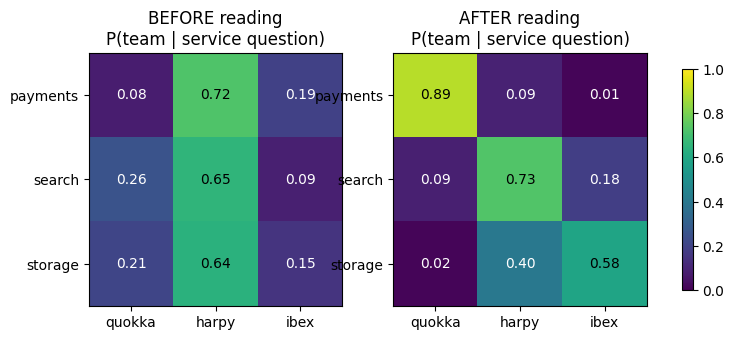

diagonal (correct) mass: 0.296 -> 0.735


In [6]:
# Cell 5 — before/after belief heatmaps
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for axx, M, title in [(axes[0], M_before, "BEFORE reading"),
                      (axes[1], M_after,  "AFTER reading")]:
    im = axx.imshow(M, vmin=0, vmax=1, cmap="viridis")
    axx.set_xticks(range(3), TEAMS); axx.set_yticks(range(3), SVCS)
    axx.set_title(f"{title}\nP(team | service question)")
    for i in range(3):
        for j in range(3):
            axx.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center",
                     color="white" if M[i,j] < 0.5 else "black")
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()
print(f"diagonal (correct) mass: {M_before.diag().mean():.3f} -> {M_after.diag().mean():.3f}")
# validated: 0.09 (guessing) -> 0.74 (knows), diagonal 3/3

## Step 5 — Hit reset. It forgets — provably.

`reset()` zeroes the fast layer. The base model was never touched, so the model
returns to *exactly* its pre-reading self — same wrong answers, bit-identical logits.
Learning that you can audit, bound, and undo.

In [7]:
# Cell 6 — the off-switch
ids = m.tok(question("payments"), return_tensors="pt").input_ids.to(m.device)
with torch.no_grad():
    logits_learned = m.model(input_ids=ids).logits.clone()
m.reset()
with torch.no_grad():
    logits_reset = m.model(input_ids=ids).logits.clone()
    m.head.B.zero_()
    logits_base  = m.model(input_ids=ids).logits.clone()

print("after reset, ask again:\n")
for s in SVCS:
    print(f"  {s:<9}→ model says: {ask(m, s)!r:<18} (truth: {OWNERS[s]})  — forgotten")
print(f"\nΔ(learned vs base) = {(logits_learned-logits_base).abs().max().item():.4f}  (>0: learning was real weight change)")
print(f"Δ(reset   vs base) = {(logits_reset-logits_base).abs().max().item():.4f}  (exactly 0: perfect undo)")
assert (logits_reset - logits_base).abs().max().item() == 0.0
print("\n✅ provable off-switch")

after reset, ask again:



  payments → model says: 'for a fix'        (truth: quokka)  — forgotten


  search   → model says: 'for a fix'        (truth: harpy)  — forgotten


  storage  → model says: 'for a fix'        (truth: ibex)  — forgotten

Δ(learned vs base) = 22.3750  (>0: learning was real weight change)
Δ(reset   vs base) = 0.0000  (exactly 0: perfect undo)

✅ provable off-switch


## What you just saw

| moment | evidence |
|---|---|
| **didn't know** | asked before: nonsense answers, P(correct) ≈ chance |
| **read** | 60 incident reports, processed by inference alone |
| **changed** | surprise ↓, fast-weight norm ↑, P(correct) ↑ — all live |
| **knows** | asked after: 3/3 correct by greedy decoding |
| **undoable** | reset → same wrong answers, Δlogits = exactly 0 |

The mechanism: a frozen 2.1B Qwen3-VL (post-tuned as a Strands-Agents expert)
plus a ~20M-parameter (<1% of the model) *plastic* layer that is updated by prediction error while
the model runs. The base can never be corrupted; the plastic layer is bounded
by decay and can be wiped at will.

**Honest footnote:** this demo uses an aggressive plasticity config
(lr 5e-2, decay 0.999, 15 passes) so you can watch it happen in minutes; it costs
a small amount of retention (strands probes Δ ≈ +0.3). The production config
(lr 8e-3, decay 0.98) learns more slowly and keeps retention at Δ ≈ 0 — that
trade-off curve is quantified in [README.md](README.md). For the skeptic-grade
proof (held-out generalization, memorization/calibration controls), see
the README.